# 03 – EDA: Wine Quality
1.599 Rotweine mit chemischen Messwerten und sensorischer Qualitätsbewertung. **Keine Vorhersage.** Lizenz: CC BY 4.0.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def datenpfad(name):
    kandidaten=[Path("daten")/name,Path("set3-datenanalyse-und-visualisierung/daten")/name,Path("../daten")/name]
    return next(p for p in kandidaten if p.exists())

wein = pd.read_csv(datenpfad("wine_quality_red.csv"), sep=";")
wein.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Struktur und Qualität

In [2]:
print("Form:", wein.shape)
print("Fehlende Werte:", int(wein.isna().sum().sum()))
print("Doppelte Zeilen:", int(wein.duplicated().sum()))
display(wein.describe().T.round(2))

Form: (1599, 12)
Fehlende Werte: 0
Doppelte Zeilen: 240


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1599.0,0.27,0.19,0.00,0.09,0.26,0.42,1.00
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
chlorides,1599.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


Ohne eindeutige ID lässt sich nicht sicher entscheiden, ob gleiche Zeilen Duplikate oder tatsächlich gleich gemessene Weine sind.

,Anzahl
quality,
3,10
4,53
5,681
6,638
7,199
8,18


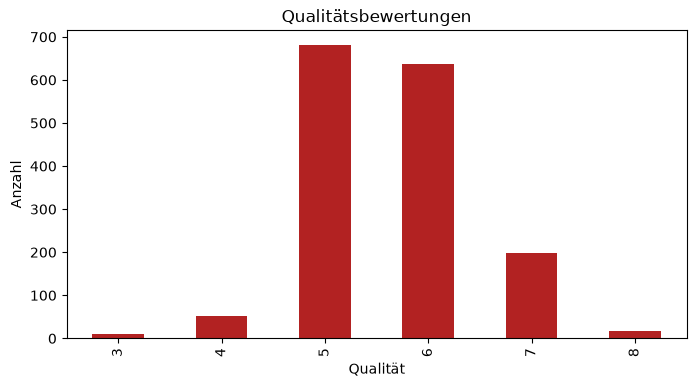

In [3]:
haeufigkeit = wein["quality"].value_counts().sort_index()
display(haeufigkeit.to_frame("Anzahl"))
ax=haeufigkeit.plot.bar(color="firebrick", figsize=(8,4), title="Qualitätsbewertungen")
ax.set(xlabel="Qualität", ylabel="Anzahl"); plt.show()

## Verteilungen und Gruppenvergleiche

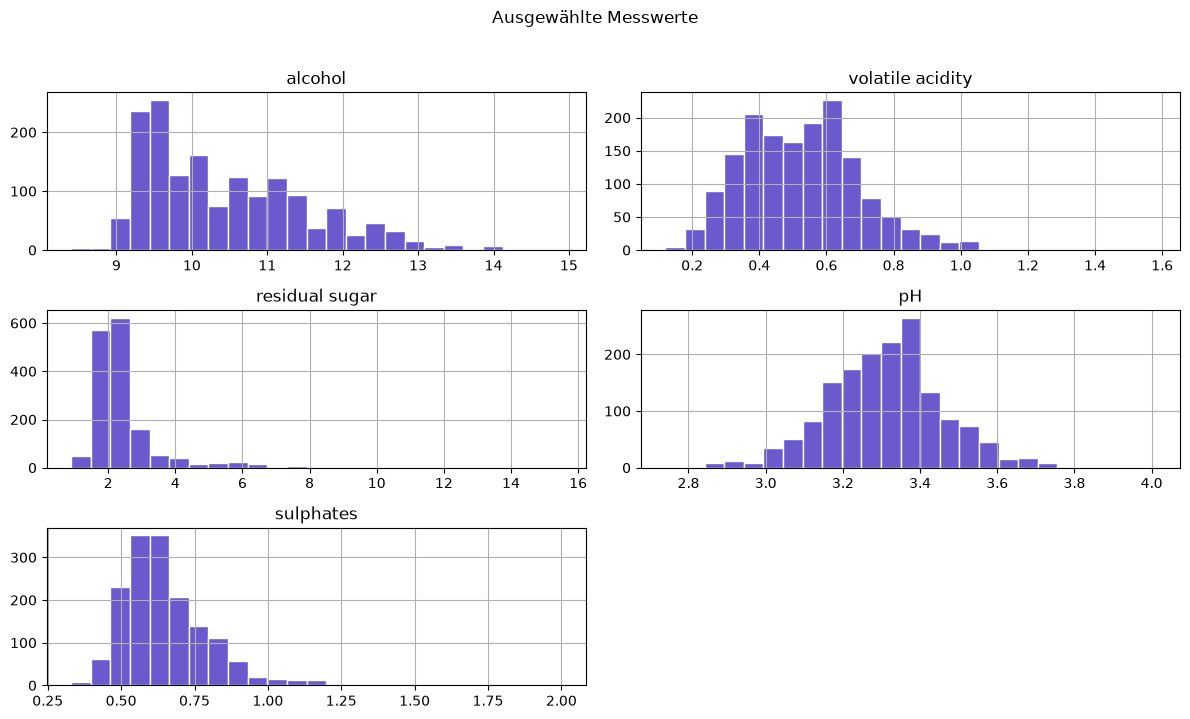

alcohol               volatile acidity              sulphates        \
          count   mean median            count  mean median     count  mean   
quality                                                                       
3            10   9.96   9.93               10  0.88   0.84        10  0.57   
4            53  10.27  10.00               53  0.69   0.67        53  0.60   
5           681   9.90   9.70              681  0.58   0.58       681  0.62   
6           638  10.63  10.50              638  0.50   0.49       638  0.68   
7           199  11.47  11.50              199  0.40   0.37       199  0.74   
8            18  12.09  12.15               18  0.42   0.37        18  0.77   

                
        median  
quality         
3         0.55  
4         0.56  
5         0.58  
6         0.64  
7         0.74  
8         0.74

In [4]:
auswahl=["alcohol","volatile acidity","residual sugar","pH","sulphates"]
wein[auswahl].hist(figsize=(12,7), bins=25, color="slateblue", edgecolor="white")
plt.suptitle("Ausgewählte Messwerte", y=1.02); plt.tight_layout(); plt.show()

display(wein.groupby("quality")[["alcohol","volatile acidity","sulphates"]].agg(["count","mean","median"]).round(2))

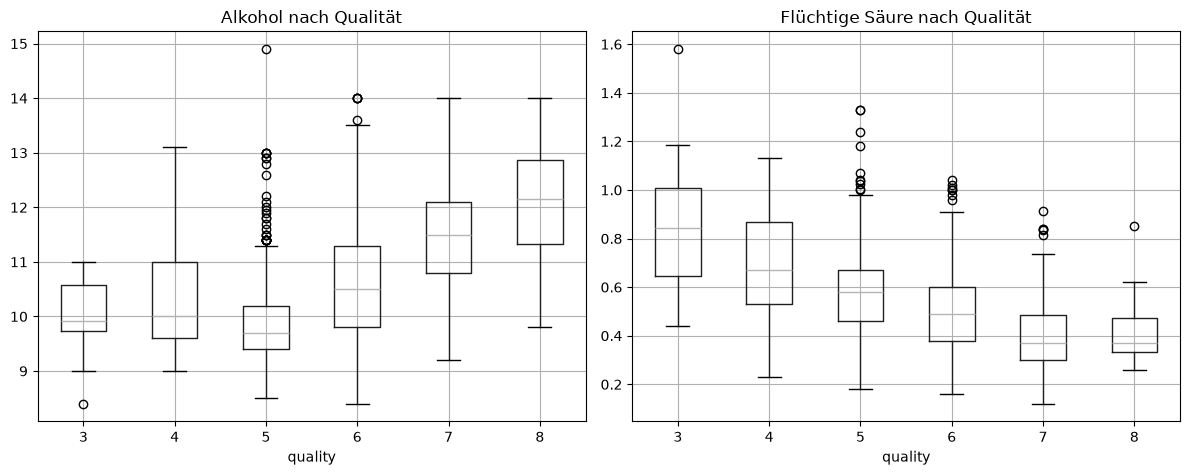

In [5]:
fig, axes=plt.subplots(1,2,figsize=(12,5))
wein.boxplot(column="alcohol",by="quality",ax=axes[0])
wein.boxplot(column="volatile acidity",by="quality",ax=axes[1])
axes[0].set_title("Alkohol nach Qualität"); axes[1].set_title("Flüchtige Säure nach Qualität")
plt.suptitle(""); plt.tight_layout(); plt.show()

## Korrelation mit der Bewertung

,Korrelation mit quality
volatile acidity,-0.391
total sulfur dioxide,-0.185
density,-0.175
chlorides,-0.129
pH,-0.058
free sulfur dioxide,-0.051
residual sugar,0.014
fixed acidity,0.124
citric acid,0.226
sulphates,0.251


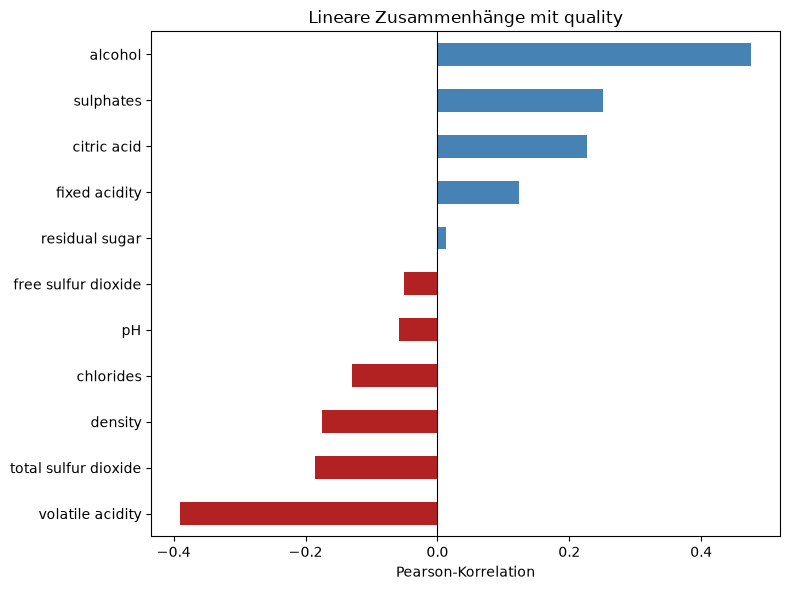

In [6]:
korr = wein.corr(numeric_only=True)["quality"].drop("quality").sort_values()
display(korr.to_frame("Korrelation mit quality").round(3))
farben=["firebrick" if x<0 else "steelblue" for x in korr]
ax=korr.plot.barh(figsize=(8,6),color=farben,title="Lineare Zusammenhänge mit quality")
ax.axvline(0,color="black",linewidth=.8); ax.set_xlabel("Pearson-Korrelation"); plt.tight_layout(); plt.show()

Eine niedrige lineare Korrelation schließt nichtlineare oder kombinierte Zusammenhänge nicht aus. Außerdem fehlen etwa Preis, Marke und Rebsorte.